In [25]:
%matplotlib inline

In [160]:
import os
import numpy as np
import matplotlib.pyplot as plt
from math import pi
# import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D
import logging
import json
import matplotlib
matplotlib.use('Agg')  # Use a non-GUI backend

In [161]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler("visualization_logs.log")
    ]
)


In [235]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import logging

def plot_global_scatter(results, output_path, legend_fontsize=24):
    """
    Generate and display a global scatter plot showing Avg Pitch vs HF Energy across all subdirectories,
    with Normal samples in green and Triggered samples in red. 
    No color bar or gradient is used.
    """

    logging.info("Creating global scatter plot...")

    # Collect data from all subdirectories
    data = {"avg_pitch": [], "hf_energy": [], "score": [], "triggered": []}
    for result in results:
        for sample_metrics in result['metrics_list']:
            data["avg_pitch"].append(sample_metrics['avg_pitch'])
            data["hf_energy"].append(sample_metrics['hf_energy'])
            data["score"].append(sample_metrics['score'])
            data["triggered"].append(sample_metrics['triggered'])

    # Filter data to exclude outliers
    filtered_indices = [
        i for i in range(len(data["avg_pitch"]))
        if data["avg_pitch"][i] <= 600 and data["hf_energy"][i] <= 200
    ]
    filtered_data = {
        key: [data[key][i] for i in filtered_indices] for key in data
    }

    # Normalize scores for marker sizes (if desired)
    normalized_scores = np.interp(
        filtered_data["score"],
        (min(filtered_data["score"]), max(filtered_data["score"])),
        (50, 500)
    )

    # Create scatter plot
    plt.figure(figsize=(14, 10))

    # Define custom legend markers
    legend_handles = []

    # We set Normal => green, Triggered => red
    # We'll keep the shape logic: circle for Normal, square for Triggered
    for t_value, marker, label, color in zip(
        [0, 1], 
        ['o', 's'], 
        ['Normal', 'Triggered'], 
        ['green', 'darkred']
    ):
        subset = [i for i, t in enumerate(filtered_data["triggered"]) if t == t_value]
        plt.scatter(
            [filtered_data["avg_pitch"][i] for i in subset],
            [filtered_data["hf_energy"][i] for i in subset],
            s=[normalized_scores[i] for i in subset],  # marker size based on score
            color=color,        # solid color (no gradient)
            alpha=0.8,
            edgecolors='w',
            linewidth=0.5,
            marker=marker,
            label=label
        )
        
        # Create custom legend markers (Static size)
        legend_handles.append(
            Line2D([0], [0], marker=marker, color='w',
                   markerfacecolor=color, markersize=28, label=label)
        )

    # Remove the colorbar entirely (no color gradient)
    # (If there was a call to plt.colorbar(), we remove it.)

    # Axis labels and ticks
    plt.xlabel('Average Pitch', fontsize=36, fontname="Times New Roman")
    plt.ylabel('High-Frequency Energy', fontsize=36, fontname="Times New Roman")
    plt.xticks(fontsize=36, fontname="Times New Roman")
    plt.yticks(fontsize=36, fontname="Times New Roman")
    plt.grid(True, linestyle='--', alpha=0.2)

    # Legend in Times New Roman
    plt.legend(
        handles=legend_handles,
        loc='upper right',
        frameon=True,
        edgecolor='black',
        prop={'family': 'Times New Roman', 'size': legend_fontsize}
    )

    # Optionally save
    file_name = "vox.png"
    save_path = os.path.join(output_path, file_name)
    plt.savefig(save_path, bbox_inches="tight", dpi=400)
    plt.close()

    plt.show()


In [236]:
results_file = "aggregated_results_vox.json"
output_path = "visualizations"

        # Load aggregated results
with open(results_file, "r") as f:
    results = json.load(f)
plot_global_scatter(results, "visualizations", legend_fontsize=36)
# logging.info(f"Loaded {len(results)} subdirectory results for visualization.")


2025-03-11 13:43:59,913 [INFO] Creating global scatter plot...


In [175]:
def plot_scatter(metrics_list, subdir_name, output_path):
    """
    Plot and save a scatter plot of Avg Pitch vs HF Energy with marker size/color by Score,
    and differentiate 'Triggered' vs 'Normal' samples.
    """
    logging.info(f"Generating scatter plot for {subdir_name}")

    # Extract relevant metrics for scatter plot
    avg_pitch = [metrics['avg_pitch'] for metrics in metrics_list]
    hf_energy = [metrics['hf_energy'] for metrics in metrics_list]
    scores = [metrics['score'] for metrics in metrics_list]
    beep_count = [metrics['beep_count'] for metrics in metrics_list]
    triggered = [metrics['triggered'] for metrics in metrics_list]

    # Determine marker sizes based on beep count
    marker_size_scale = 200
    sizes = [(bc + 1) * marker_size_scale for bc in beep_count]

    # Create scatter plot
    plt.figure(figsize=(12, 8))

    # Plot Triggered and Normal samples with different markers
    for t_value, marker in zip([0, 1], ['o', 's']):
        subset = [i for i, t in enumerate(triggered) if t == t_value]
        plt.scatter(
            [avg_pitch[i] for i in subset],
            [hf_energy[i] for i in subset],
            c=[scores[i] for i in subset],  # Color based on score
            s=[sizes[i] for i in subset],  # Size based on beep count
            cmap='viridis',
            alpha=0.8,
            edgecolors='w',
            linewidth=0.5,
            marker=marker
        )

    # Add legend
    legend_handles = [
        Line2D([0], [0], marker='o', color='black', label='Normal', markersize=10, linestyle='None'),
        Line2D([0], [0], marker='s', color='black', label='Triggered', markersize=10, linestyle='None')
    ]
    plt.legend(handles=legend_handles, title="", loc='best', fontsize=12)

    # Add colorbar and labels
    colorbar = plt.colorbar()
    colorbar.set_label('Score Intensity (Higher is brighter)', size=14)

    plt.title(f"Avg Pitch vs HF Energy - {subdir_name}", size=18)
    plt.xlabel('Average Pitch', size=16)
    plt.ylabel('High-Frequency Energy', size=16)
    plt.xticks(size=14)
    plt.yticks(size=14)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Save the scatter plot
    file_name = f"{subdir_name}_scatter_plot.png"
    save_path = os.path.join(output_path, file_name)
    plt.savefig(save_path)
    plt.close()

    logging.info(f"Saved scatter plot for {subdir_name} to {save_path}")


In [176]:
def calculate_attack_success_rate(results):
    """
    Calculate the attack success rate (ASR) and performance metrics
    based on the provided results.
    """
    # Initialize lists for subdirectory categorization
    correctly_triggered = []
    misclassified_as_normal = []
    misclassified_as_triggered = []
    deferred = []
    correctly_normal = []

    # Iterate over results to calculate metrics
    for result in results:
        # Normalize subdirectory name and decision
        subdir_name = result['subdirectory'].strip()
        decision_raw = result['decision'].strip().lower()  # Normalize decision

        # Determine if the subdirectory is a triggered account
        is_triggered = subdir_name.endswith("_t")

        # Classify subdirectories based on their decisions
        if decision_raw == "triggered":
            if is_triggered:  # Correctly classified as Triggered
                correctly_triggered.append(subdir_name)
            else:  # Misclassified Normal as Triggered
                misclassified_as_triggered.append(subdir_name)

        elif decision_raw == "normal":
            if is_triggered:  # Triggered misclassified as Normal
                misclassified_as_normal.append(subdir_name)
            else:  # Correctly classified as Normal
                correctly_normal.append(subdir_name)

        elif decision_raw == "deferred":
            deferred.append(subdir_name)

    # Calculate numbers directly from lists
    triggered_correct = len(correctly_triggered)
    triggered_incorrect = len(misclassified_as_triggered)
    normal_correct = len(correctly_normal)
    normal_incorrect = len(misclassified_as_normal)
    deferred_count = len(deferred)
    total_triggered = triggered_correct + normal_incorrect

    # Calculate overall accuracy and attack success rate (ASR)
    total_samples = len(results)
    accuracy = (triggered_correct + normal_correct) / total_samples if total_samples > 0 else 0
    asr = (triggered_correct / total_triggered * 100) if total_triggered > 0 else 100

    # Return metrics and categorized subdirectory lists
    return {
        "total_samples": total_samples,
        "total_triggered": total_triggered,
        "triggered_correct": triggered_correct,
        "triggered_incorrect": triggered_incorrect,
        "normal_correct": normal_correct,
        "normal_incorrect": normal_incorrect,
        "deferred_count": deferred_count,
        "accuracy": accuracy,
        "attack_success_rate": asr,
        "correctly_triggered": correctly_triggered,
        "misclassified_as_normal": misclassified_as_normal,
        "misclassified_as_triggered": misclassified_as_triggered,
        "deferred": deferred,
        "correctly_normal": correctly_normal,
    }


In [177]:
def process_results(json_file, output_path):
    """
    Process results from a JSON file, calculate metrics, and generate reports.
    """
    with open(json_file, "r") as file:
        results = json.load(file)

    metrics = calculate_attack_success_rate(results)

    # Generate detailed batch-wise and final reports
    # generate_table_report(results, output_path)  # Print table and save to file
    generate_bar_chart(metrics, output_path)
    # generate_confusion_matrix(metrics, output_path)
    # generate_terminal_report(metrics)

    # Final list of subdirectories
    # print("\n================= Final Subdirectory Summary =================")
    # print("Correctly Classified as Triggered:", metrics["correctly_triggered"])
    # print("Misclassified as Normal:", metrics["misclassified_as_normal"])
    # print("Deferred Decisions:", metrics["deferred"])
    # print("Misclassified as Triggered:", metrics["misclassified_as_triggered"])
    # print("Correctly Classified as Normal:", metrics["correctly_normal"])
    # print("============================================================\n")

    return metrics

In [219]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

def generate_bar_chart(metrics, output_path):
    """
    Generate a stacked bar chart summarizing decisions and display it in Jupyter Lab.
    All fonts are Times New Roman at size 28, and bar labels are bold and black.
    If a bar segment is 'short' (under a chosen threshold), the label is placed above it.
    """

    # -- Set global font properties for Matplotlib --
    mpl.rcParams['font.family'] = 'Times New Roman'
    mpl.rcParams['font.size'] = 28

    categories = ["Triggered", "Normal", "Deferred"]
    correct_counts = [metrics["triggered_correct"], metrics["normal_correct"], 0]
    incorrect_counts = [metrics["triggered_incorrect"], metrics["normal_incorrect"], metrics["deferred_count"]]

    df = pd.DataFrame({"Correct": correct_counts, "Incorrect": incorrect_counts}, index=categories)

    plt.figure(figsize=(10, 6))
    bars = df.plot(
        kind="bar",
        stacked=True,
        color=["#4CAF50", "#E74C3C"],
        alpha=0.85,
        edgecolor="black",
        figsize=(10, 6)
    )

    # Threshold for deciding if the bar segment is "too small" to label in-center
    height_threshold = 113
    offset_above = 2       # vertical offset when placing label above the bar

    # Add numeric labels on the bars
    for bar in bars.patches:
        height = bar.get_height()
        if height > 0:
            # If the bar is "short," place label above; else place it in the center
            if height == 59 or height == 28:
                y_pos = bar.get_y() + height + offset_above
                va_setting = "bottom"
            elif 29 <height < 39:
                y_pos = bar.get_y() + height + offset_above
                va_setting = "bottom"
            else:
                y_pos = bar.get_y() + (height / 2)
                va_setting = "center"

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                y_pos,
                f"{int(height)}",
                ha="center",
                va=va_setting,
                fontweight="bold",
                color="black"
            )

    plt.xlabel("Decision Categories", fontsize=28)
    plt.ylabel("Count", fontsize=28)
    plt.xticks(rotation=0)
    plt.yticks()
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Legend in Times New Roman, size 28
    plt.legend(title="Classification", prop={'size': 28}, frameon=True)

    # Save the chart to file
    chart_path = os.path.join(output_path, "voxceleb_stacked_decision_summary_chart.png")
    plt.tight_layout()
    plt.savefig(chart_path, dpi=400)

    # Display the plot immediately in Jupyter Lab
    plt.show()

    # print(f"Stacked bar chart saved to {chart_path}")


<Figure size 1000x600 with 0 Axes>

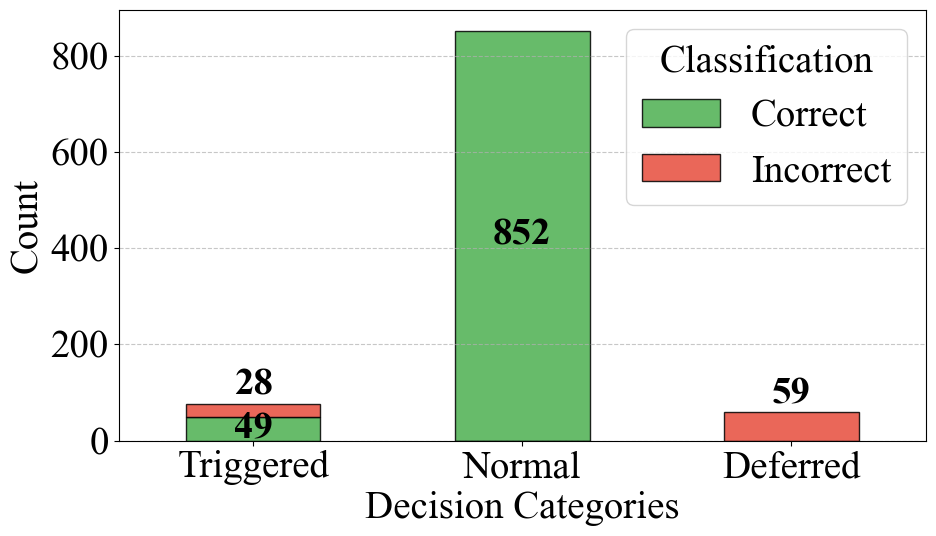

In [220]:
json_file = "aggregated_results_vox.json"
output_path = "./output"
os.makedirs(output_path, exist_ok=True)

metrics = process_results(json_file, output_path)
# print(f"Results processed successfully. Reports and visualizations saved to {output_path}")

In [239]:
def visualize_results(results, output_path):
    """
    Generate visualizations for the analysis results. Includes user interaction for selecting subdirectories.
    """
    logging.info("Starting visualization generation.")
    os.makedirs(output_path, exist_ok=True)

    # Calculate fixed range dynamically from all results
    fixed_range = calculate_fixed_range(results)

    # Step 1: Generate global visualizations (Default)
    logging.info("Generating global visualizations.")
    plot_global_scatter(results, output_path)

    # Generate combined radar plots for all subdirectories by default
    for result in results:
        metrics_list = result['metrics_list']
        subdir_name = result['subdirectory']
        plot_combined_radar(metrics_list, subdir_name, output_path, fixed_range)

    logging.info("Default visualizations (global scatter plot and combined radar plots) generated.")

    # Step 2: Prompt user for further visualizations
    print("\nWould you like to generate additional visualizations (individual radar plots, scatter plots, or heatmaps) "
          "for specific subdirectories?")
    user_choice = input("Enter 'yes' to proceed or 'skip' to skip additional visualizations: ").strip().lower()

    if user_choice == "skip":
        logging.info("User chose to skip additional visualizations.")
        print("Skipping additional visualizations.")
        return

    # Show available subdirectory names
    subdirectory_names = [result['subdirectory'] for result in results]
    print("\nAvailable subdirectories:")
    for idx, subdir in enumerate(subdirectory_names, 1):
        print(f"{idx}. {subdir}")

    # Step 3: User selects subdirectories
    selected_subdirs = []
    while not selected_subdirs:
        user_input = input("\nEnter the subdirectory names (comma-separated) from the list above, "
                        "or enter 'skip' to skip: ").strip()

        if user_input.lower() == "skip":
            logging.info("User skipped individual subdirectory visualizations.")
            print("Skipping individual subdirectory visualizations.")
            return

        # Normalize the input
        user_input = user_input.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
        user_input = user_input.replace(" ", "").strip()
        
        # Split input into names
        entered_names = user_input.split(",")

        # Filter valid names
        selected_subdirs = [name for name in entered_names if name in subdirectory_names]

        if not selected_subdirs:
            print("Invalid input. Please enter valid subdirectory names from the list.")
            logging.warning("Invalid subdirectory names provided by user.")
        else:
            invalid_names = [name for name in entered_names if name not in subdirectory_names]
            if invalid_names:
                print(f"Invalid subdirectory names detected: {', '.join(invalid_names)}. "
                    f"Only the following valid names will be processed: {', '.join(selected_subdirs)}.")
            else:
                print(f"Selected subdirectories: {', '.join(selected_subdirs)}")

    # Step 4: User selects visualization types
    print("\nAvailable visualization types:")
    print("1. Individual Radar Plots")
    print("2. Scatter Plots")
    print("3. Heatmaps")
    print("4. All of the above")

    visualization_types = []
    while not visualization_types:
        user_input = input("\nEnter the numbers corresponding to the visualization types (comma-separated, e.g., '1,3'), "
                           "or enter 'skip' to skip: ").strip()
        if user_input.lower() == "skip":
            logging.info("User skipped visualization type selection.")
            print("Skipping visualization type selection.")
            return

        # Parse input and validate
        valid_choices = {"1", "2", "3", "4"}
        visualization_types = [choice.strip() for choice in user_input.split(",") if choice.strip() in valid_choices]
        if not visualization_types:
            print("Invalid input. Please enter valid numbers corresponding to the visualization types.")

    # Step 5: Generate selected visualizations
    for subdir_name in selected_subdirs:
        result = next((res for res in results if res['subdirectory'] == subdir_name), None)
        if not result:
            continue

        metrics_list = result['metrics_list']

        if "4" in visualization_types or "1" in visualization_types:  # Individual Radar Plots
            for idx, sample_metrics in enumerate(metrics_list):
                plot_radar_chart(sample_metrics, subdir_name, idx, output_path, fixed_range)

        if "4" in visualization_types or "2" in visualization_types:  # Scatter Plots
            plot_scatter(metrics_list, subdir_name, output_path)

        if "4" in visualization_types or "3" in visualization_types:  # Heatmaps
            plot_heatmap(metrics_list, subdir_name, output_path)

    logging.info("User-selected visualizations have been successfully generated.")
    print("Visualizations for the selected subdirectories have been generated.")


In [265]:
def plot_combined_radar(metrics_list, subdir_name, output_path, fixed_range):
    """
    Generate and save a combined radar chart for all samples in a subdirectory.
    Fonts changed to Times New Roman and the score legend removed.
    """
    logging.info(f"Creating combined radar plot for subdirectory: {subdir_name}")
    all_values = []

    for sample_metrics in metrics_list:
        # Normalize the metrics using the fixed range
        normalized_metrics = {
            key: (value - min_val) / (max_val - min_val)
            for key, value in sample_metrics.items()
            if key in fixed_range
            for min_val, max_val in [fixed_range[key]]
        }
        all_values.append(list(normalized_metrics.values()))

    num_vars = len(fixed_range)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]

    plt.figure(figsize=(12, 12))
    ax = plt.subplot(111, polar=True)

    label_mapping = {
        "pitch_variance": "Pitch Var",
        "avg_pitch": "Pitch Avg",
        "avg_beep_interval": "Avg \n Beep \n Interval",
        "hf_energy": "HF Energy",
        "hf_energy_variance": "HF Var",
        "hf_var_to_avg_ratio": "HF \n Var/Avg \n Ratio",
        "pitch_var_to_avg_ratio": "Pitch \n Var/Avg \n Ratio"
    }
    category_keys = list(fixed_range.keys())
    display_labels = [label_mapping.get(k, k) for k in category_keys]


    # Apply Times New Roman font
    plt.xticks(angles[:-1], display_labels, fontname="Times New Roman", size=58)  # Doubled font size

    ax.set_rlabel_position(80)  # Move radial labels away from plotted line if desired
    radial_ticks = [0.2, 0.4, 0.6, 0.8, 1.0]  # Example radial ticks
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels(
        [str(t) for t in radial_ticks],
        fontname="Times New Roman", 
        size=58  # Increase/decrease as needed
    )


    for idx, values in enumerate(all_values):
        values += values[:1]
        triggered = metrics_list[idx].get("triggered", 0)
        color = "yellow" if triggered == 1 else "blue"
        ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=sample_metrics.get("label", f"Sample {idx+1}"))
        ax.fill(angles, values, color=color, alpha=0.1)

    # ax.legend(
    #     loc='lower right',
    #     bbox_to_anchor=(1.4, -0.35),
    #     prop={'family': 'Times New Roman', 'size': 26},  # Ensure font change
    # )

    # plt.title(f"Combined Radar Plot - {subdir_name}", size=36, y=1.1, fontname="Times New Roman", color='black')  # Doubled size
    plt.tight_layout()
    file_name = f"{subdir_name}_combined_radar_plot.png"
    plt.savefig(os.path.join(output_path, file_name), bbox_inches="tight")
    plt.close()
    logging.info(f"Radar plot saved to {os.path.join(output_path, file_name)}.")


In [ ]:
logging.info("Starting the script execution.")
# Replace this with the actual path to your results and output
results_file = "aggregated_results_lib_vox_mix.json"
output_path = "visualizations"

# Load aggregated results
with open(results_file, "r") as f:
    results = json.load(f)
logging.info(f"Loaded {len(results)} subdirectory results for visualization.")

# Generate visualizations
visualize_results(results, output_path)
logging.info("Visualization script execution completed successfully.")

2025-03-11 19:25:11,438 [INFO] Starting the script execution.
2025-03-11 19:25:11,584 [INFO] Loaded 2558 subdirectory results for visualization.
2025-03-11 19:25:11,585 [INFO] Starting visualization generation.
2025-03-11 19:25:11,586 [INFO] Calculating fixed range for metrics across all results.
2025-03-11 19:25:11,631 [INFO] Fixed range calculated: {'avg_beep_interval': (0.0, 2.976), 'avg_pitch': (0.0, 937.7457055659683), 'pitch_variance': (0.0, 136900.41154449427), 'hf_energy': (0.2820914685726166, 293.20147705078125), 'hf_energy_variance': (0.009905424900352955, 227059.59375), 'pitch_var_to_avg_ratio': (0.0, 389.43714338443164), 'hf_var_to_avg_ratio': (0.012055655010044575, 1530.6531982421875)}
2025-03-11 19:25:11,632 [INFO] Generating global visualizations.
2025-03-11 19:25:11,632 [INFO] Creating global scatter plot...
2025-03-11 19:25:14,611 [INFO] Creating combined radar plot for subdirectory: 0776
2025-03-11 19:25:14,771 [INFO] Radar plot saved to visualizations\0776_combined_r


Would you like to generate additional visualizations (individual radar plots, scatter plots, or heatmaps) for specific subdirectories?
